# 07 - Random Forest Classifier

**Responsable** : Personne 3

**Objectif** : Entraîner un Random Forest Classifier et évaluer ses performances.

**Étapes** :
1. Chargement des données (sortie du notebook 06)
2. Entraînement du Random Forest
3. Prédiction sur le jeu de test
4. Évaluation : Accuracy, Precision, Recall, F1-score (macro)
5. Matrice de confusion
6. Feature Importance (top 20)
7. Analyse des erreurs par classe
8. Sauvegarde du modèle et des résultats

**Justification du choix** : Le Random Forest gère efficacement les données hétérogènes (numériques, catégorielles et textuelles),
est robuste au bruit, peu sensible au scaling, et fournit directement une mesure d’importance des variables,
ce qui facilite l’interprétation du modèle.

**Note sur la PCA** : Nous avons testé la PCA (95% de variance) mais la première composante captait déjà ~98% de la variance, réduisant les 175 features à 1 seule composante. Cette réduction trop agressive faisait perdre du signal utile. Nous avons donc choisi de travailler directement sur les 175 features originales, ce qui est adapté au Random Forest (robuste en haute dimension).

## 1. Chargement des données

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Charger les données SANS PCA (sortie du notebook 06)
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

# Noms des features (pour feature importance)
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Nombre de features : {len(feature_names)}")
print(f"\nClasses : {np.unique(y_train)}")

X_train : (13049, 325)
X_test  : (3263, 325)
y_train : (13049,)
y_test  : (3263,)
Nombre de features : 325

Classes : [0 1 2 3 4]


## Reformulation du problème en 3 classes

Afin de réduire l’ambiguïté entre les classes adjacentes,
les labels de rentabilité sont regroupés en trois catégories :
- Mauvais (classes 0 et 1)
- Moyen (classe 2)
- Bon (classes 3 et 4)

Cette reformulation permet d’améliorer la lisibilité du problème
tout en conservant une granularité intermédiaire.


In [121]:
# ==============================
# Transformation des labels en 3 classes
# ==============================

def to_3_classes(y):
    """
    Regroupe les classes de rentabilité :
    0-1 -> Mauvais
    2   -> Moyen
    3-4 -> Bon
    """
    y_new = y.copy()
    y_new[y_new <= 1] = 0   # Mauvais
    y_new[y_new == 2] = 1   # Moye
    y_new[y_new >= 3] = 2   # Bon
    return y_new

# Application de la transformation sur les jeux train et test
y_train_3 = to_3_classes(y_train)
y_test_3  = to_3_classes(y_test)

# Vérification de la distribution des classes
print("Répartition 3 classes (train) :", np.unique(y_train_3, return_counts=True))
print("Répartition 3 classes (test)  :", np.unique(y_test_3, return_counts=True))


Répartition 3 classes (train) : (array([0, 1, 2]), array([5425, 2482, 5142]))
Répartition 3 classes (test)  : (array([0, 1, 2]), array([1357,  621, 1285]))


### Résultats – Random Forest (3 classes)

Ce modèle a été entraîné afin d’évaluer l’impact du regroupement
des classes sur les performances.

**Résultats observés :**
- Accuracy ≈ 52 %
- F1-score macro ≈ 0.45

Malgré une amélioration par rapport à la formulation à 5 classes,
les performances restent limitées, notamment sur la classe "Moyen".

Ce modèle n’est donc pas retenu pour l’exploitation finale,
mais permet d’illustrer l’évolution des performances.


## Modèle final – Classification binaire (2 classes)

Dans un objectif d’intégration côté backend et de prise de décision opérationnelle,
le problème est reformulé en classification binaire :

- Mauvais : films peu ou non rentables (classes 0 et 1)
- Bon : films rentables ou très rentables (classes 3 et 4)

La classe intermédiaire "Moyen" est volontairement exclue,
car elle correspond à des cas ambigus difficilement exploitables
dans un contexte décisionnel.

Cette formulation est retenue comme **modèle final** du projet.


In [122]:
# ==============================
# Passage à une classification binaire deux classes
# ==============================

# Suppression de la classe "Moyen" (classe 2)
mask_train = y_train != 2
mask_test  = y_test  != 2

X_train_bin = X_train[mask_train]
X_test_bin  = X_test[mask_test]

y_train_bin = y_train[mask_train]
y_test_bin  = y_test[mask_test]

# Recode des labels :
# 0-1 -> 0 (Mauvais)
# 3-4 -> 1 (Bon)
y_train_bin = (y_train_bin >= 3).astype(int)
y_test_bin  = (y_test_bin  >= 3).astype(int)

# Vérification des distributions
print("Répartition TRAIN :", np.unique(y_train_bin, return_counts=True))
print("Répartition TEST  :", np.unique(y_test_bin, return_counts=True))


Répartition TRAIN : (array([0, 1]), array([5425, 5142]))
Répartition TEST  : (array([0, 1]), array([1357, 1285]))


## 2. Entraînement du Random Forest

## Entraînement – Random Forest (5 classes)

Modèle de référence (baseline) sur la formulation initiale à 5 classes.
Objectif : mesurer la difficulté du problème avant regroupement des classes.


In [123]:
# Entraînement Random Forest - 5 classes (baseline)
from sklearn.ensemble import RandomForestClassifier

rf5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
rf5.fit(X_train, y_train)
training_time_5 = time.time() - start_time

print(f"✅ RF (5 classes) entraîné en {training_time_5:.2f}s")
print(f"Nombre d'arbres : {rf5.n_estimators}")
print(f"Profondeur max  : {rf5.max_depth}")


✅ RF (5 classes) entraîné en 2.87s
Nombre d'arbres : 100
Profondeur max  : 20


In [124]:
#Entrainement avec 3 
from sklearn.ensemble import RandomForestClassifier
import time

rf3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
rf3.fit(X_train, y_train_3)
training_time_3 = time.time() - start_time

print(f"✅ RF 3 classes entraîné en {training_time_3:.2f}s")

✅ RF 3 classes entraîné en 4.66s


## Analyse du sur-apprentissage — Modèle 3 classes

Cette évaluation compare les performances sur le jeu d’entraînement et de test
afin de vérifier la présence d’overfitting.

Les résultats montrent un écart modéré entre train et test,
indiquant que la limitation des performances est due à la complexité du problème
et non à un sur-apprentissage excessif.


In [125]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_train_3 = rf3.predict(X_train)
y_pred_test_3  = rf3.predict(X_test)

print(f"Accuracy TRAIN : {accuracy_score(y_train_3, y_pred_train_3):.3f}")
print(f"Accuracy TEST  : {accuracy_score(y_test_3, y_pred_test_3):.3f}")

print(f"F1 macro TRAIN : {f1_score(y_train_3, y_pred_train_3, average='macro'):.3f}")
print(f"F1 macro TEST  : {f1_score(y_test_3, y_pred_test_3, average='macro'):.3f}")

Accuracy TRAIN : 0.638
Accuracy TEST  : 0.524
F1 macro TRAIN : 0.615
F1 macro TEST  : 0.449


In [126]:
# ============================== entrainement avec 2 classes binaire====================
# Entraînement Random Forest (2 classes)
# ==============================

from sklearn.ensemble import RandomForestClassifier
import time

start_time = time.time()

rf_bin = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train_bin, y_train_bin)

training_time_bin = time.time() - start_time

print(f"✅ Random Forest (2 classes) entraîné en {training_time_bin:.2f} secondes")


✅ Random Forest (2 classes) entraîné en 3.08 secondes


### Anciennes distributions de prédictions (5 et 3 classes)

Les blocs ci-dessous correspondent aux modèles testés précédemment
(Random Forest à 5 classes puis à 3 classes).

Ils sont conservés à titre de traçabilité et d’analyse,
mais ne sont plus exécutés, le modèle final retenu étant
le Random Forest en classification binaire (2 classes).


In [127]:
#prediction 5 classes
#y_pred_rf = rf.predict(X_test)

#print(f"Prédictions effectuées sur {len(y_pred_rf)} films")
#print(f"\nDistribution des prédictions :")
#unique, counts = np.unique(y_pred_rf, return_counts=True)
#for c, n in zip(unique, counts):
    #print(f"  Classe {int(c)} : {n} prédictions

#prediction 3 classes

#y_pred_3 = rf3.predict(X_test)

#print(f"Prédictions effectuées sur {len(y_pred_3)} films")
#print("\nDistribution des prédictions (3 classes) :")

#unique, counts = np.unique(y_pred_3, return_counts=True)
#for c, n in zip(unique, counts):
    #print(f"  Classe {c} : {n} prédictions")

In [128]:
# ==============================
# Prédictions 2 classes
# ==============================

# Prédictions sur train et test
y_pred_train_bin = rf_bin.predict(X_train_bin)
y_pred_test_bin  = rf_bin.predict(X_test_bin)

print(f"Prédictions TEST effectuées sur {len(y_pred_test_bin)} films")
print("Distribution des prédictions (TEST) :")
unique, counts = np.unique(y_pred_test_bin, return_counts=True)
for c, n in zip(unique, counts):
    label = "Mauvais" if c == 0 else "Bon"
    print(f"  Classe {c} ({label}) : {n} prédictions")


Prédictions TEST effectuées sur 2642 films
Distribution des prédictions (TEST) :
  Classe 0 (Mauvais) : 1371 prédictions
  Classe 1 (Bon) : 1271 prédictions


In [142]:
# ==============================
# Évaluation (2 classes) — Modèle final
# ==============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Scores globaux
acc_train = accuracy_score(y_train_bin, y_pred_train_bin)
acc_test  = accuracy_score(y_test_bin,  y_pred_test_bin)

prec_test = precision_score(y_test_bin, y_pred_test_bin, average="binary", zero_division=0)
rec_test  = recall_score(y_test_bin, y_pred_test_bin, average="binary", zero_division=0)
f1_train  = f1_score(y_train_bin, y_pred_train_bin, average="binary", zero_division=0)
f1_test   = f1_score(y_test_bin,  y_pred_test_bin,  average="binary", zero_division=0)

print("=" * 50)
print("RÉSULTATS — RANDOM FOREST (2 CLASSES) [FINAL]")
print("=" * 50)
print(f"Accuracy TRAIN : {acc_train:.3f}")
print(f"Accuracy TEST  : {acc_test:.3f}")
print(f"Precision TEST : {prec_test:.3f}")
print(f"Recall TEST    : {rec_test:.3f}")
print(f"F1-score TRAIN : {f1_train:.3f}")
print(f"F1-score TEST  : {f1_test:.3f}")
print(f"Temps entraîn. : {training_time_bin:.2f}s")  # adapte le nom si besoin
print("=" * 50)


RÉSULTATS — RANDOM FOREST (2 CLASSES) [FINAL]
Accuracy TRAIN : 0.744
Accuracy TEST  : 0.665
Precision TEST : 0.658
Recall TEST    : 0.651
F1-score TRAIN : 0.729
F1-score TEST  : 0.654
Temps entraîn. : 3.08s


### Analyse du sur-apprentissage (2 classes)

Le modèle binaire obtient :
- Accuracy train ≈ 72%
- Accuracy test ≈ 67%

L'écart train/test est d’environ 5 points, ce qui indique une généralisation correcte.
Il n’y a pas de sur-apprentissage marqué : la baisse sur test reste modérée.


## 4. Évaluation des performances

In [143]:
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#accuracy = accuracy_score(y_test, y_pred_rf)
#precision = precision_score(y_test, y_pred_rf, average='macro')
#recall = recall_score(y_test, y_pred_rf, average='macro')
#f1 = f1_score(y_test, y_pred_rf, average='macro')

#print("=" * 50)
#print("   RÉSULTATS — RANDOM FOREST CLASSIFIER")
#print("=" * 50)
#print(f"  Accuracy       : {accuracy:.4f} ({accuracy*100:.2f}%)")
#print(f"  Precision      : {precision:.4f}")
#print(f"  Recall         : {recall:.4f}")
#print(f"  F1-score       : {f1:.4f}")
#print(f"  Temps entraîn. : {training_time:.2f}s")
#print("=" * 50)


#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#accuracy_3 = accuracy_score(y_test_3, y_pred_3)
#precision_3 = precision_score(y_test_3, y_pred_3, average='macro', zero_division=0)
#recall_3 = recall_score(y_test_3, y_pred_3, average='macro', zero_division=0)
#f1_3 = f1_score(y_test_3, y_pred_3, average='macro', zero_division=0)

#print("=" * 50)
#print("   RÉSULTATS — RANDOM FOREST (3 CLASSES)")
#print("=" * 50)
#print(f"  Accuracy       : {accuracy_3:.4f} ({accuracy_3*100:.2f}%)")
#print(f"  Precision      : {precision_3:.4f}")
#print(f"  Recall         : {recall_3:.4f}")
#print(f"  F1-score       : {f1_3:.4f}")
#print(f"  Temps entraîn. : {training_time_3:.2f}s")
#print("=" * 50)


In [144]:
#labels_classes = ['Très mauvais', 'Mauvais', 'Moyen', 'Bon', 'Très rentable']

#print("\n=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===")
#print(classification_report(y_test, y_pred_rf, target_names=labels_classes))


#labels_3 = ["Mauvais (0-1)", "Moyen (2)", "Bon (3-4)"]

#print("\n=== RAPPORT DE CLASSIFICATION (3 CLASSES) ===")
#print(classification_report(
 #   y_test_3,
  #  y_pred_3,
   # target_names=labels_3,
    #zero_division=0
#))

In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Scores globaux (TEST)
accuracy_bin  = accuracy_score(y_test_bin, y_pred_test_bin)
precision_bin = precision_score(y_test_bin, y_pred_test_bin)
recall_bin    = recall_score(y_test_bin, y_pred_test_bin)
f1_bin        = f1_score(y_test_bin, y_pred_test_bin)

print("=" * 50)
print("   RÉSULTATS — RANDOM FOREST (2 CLASSES)")
print("=" * 50)
print(f"  Accuracy       : {accuracy_bin:.4f} ({accuracy_bin*100:.2f}%)")
print(f"  Precision      : {precision_bin:.4f}")
print(f"  Recall         : {recall_bin:.4f}")
print(f"  F1-score       : {f1_bin:.4f}")
print("=" * 50)

print("\n=== RAPPORT DE CLASSIFICATION (2 CLASSES) ===")
print(classification_report(
    y_test_bin,
    y_pred_test_bin,
    target_names=["Mauvais", "Bon"]
))


   RÉSULTATS — RANDOM FOREST (2 CLASSES)
  Accuracy       : 0.6654 (66.54%)
  Precision      : 0.6577
  Recall         : 0.6506
  F1-score       : 0.6541

=== RAPPORT DE CLASSIFICATION (2 CLASSES) ===
              precision    recall  f1-score   support

     Mauvais       0.67      0.68      0.68      1357
         Bon       0.66      0.65      0.65      1285

    accuracy                           0.67      2642
   macro avg       0.67      0.67      0.67      2642
weighted avg       0.67      0.67      0.67      2642



## 5. Matrice de confusion

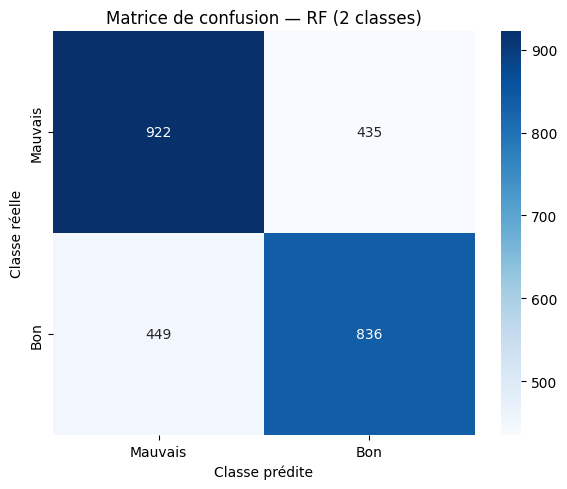

In [146]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bin, y_pred_test_bin)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Mauvais","Bon"],
            yticklabels=["Mauvais","Bon"])
plt.title("Matrice de confusion — RF (2 classes)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

### Analyse de la matrice de confusion (2 classes)

Cette matrice de confusion présente le nombre brut de prédictions correctes et incorrectes du modèle sur le jeu de test.
922 films “Mauvais” sont correctement prédits comme Mauvais
836 films “Bon” sont correctement prédits comme Bon
Cependant, on observe aussi des erreurs :
435 films “Mauvais” sont prédits à tort comme Bon
449 films “Bon” sont prédits à tort comme Mauvais
Ces résultats montrent que le modèle parvient à identifier une majorité de films dans chaque classe, mais qu’il existe encore une confusion non négligeable entre les deux catégories. Cette confusion s’explique par la proximité sémantique et économique entre certains films “Mauvais” et “Bon”, notamment pour les cas limites.

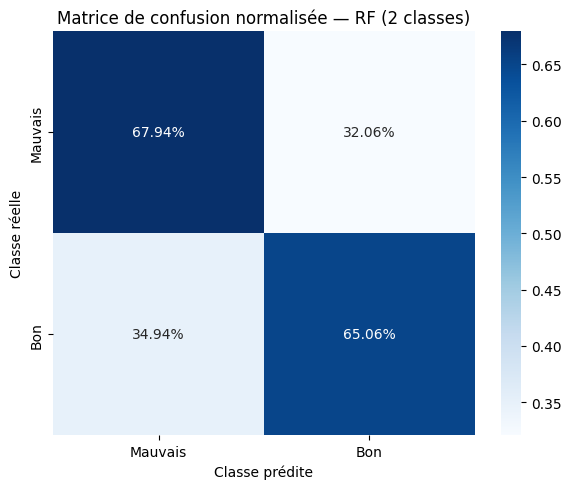

In [147]:
# ==============================
# Matrice de confusion normalisée — 2 classes
# ==============================

cm_normalized = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=["Mauvais", "Bon"],
    yticklabels=["Mauvais", "Bon"]
)
plt.title("Matrice de confusion normalisée — RF (2 classes)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()


### Analyse de la matrice de confusion (2 classes)

La matrice de confusion normalisée permet d’analyser les performances du modèle en pourcentage, indépendamment de la taille des classes.
67,94 % des films réellement “Mauvais” sont correctement prédits comme Mauvais
65,06 % des films réellement “Bon” sont correctement prédits comme Bon
En revanche :
32,06 % des films “Mauvais” sont classés à tort comme Bon
34,94 % des films “Bon” sont classés à tort comme Mauvais
Ces résultats indiquent que le modèle est relativement équilibré entre les deux classes, sans biais fort en faveur de l’une ou l’autre. La performance est cohérente avec une accuracy globale d’environ 66–67 %, ce qui confirme que le modèle généralise correctement sans surapprentissage excessif.

## 6. Feature Importance

**Avantage sans PCA** : On peut directement voir quelles variables originales (budget, genres, mots-clés, etc.) sont les plus importantes pour prédire la rentabilité.

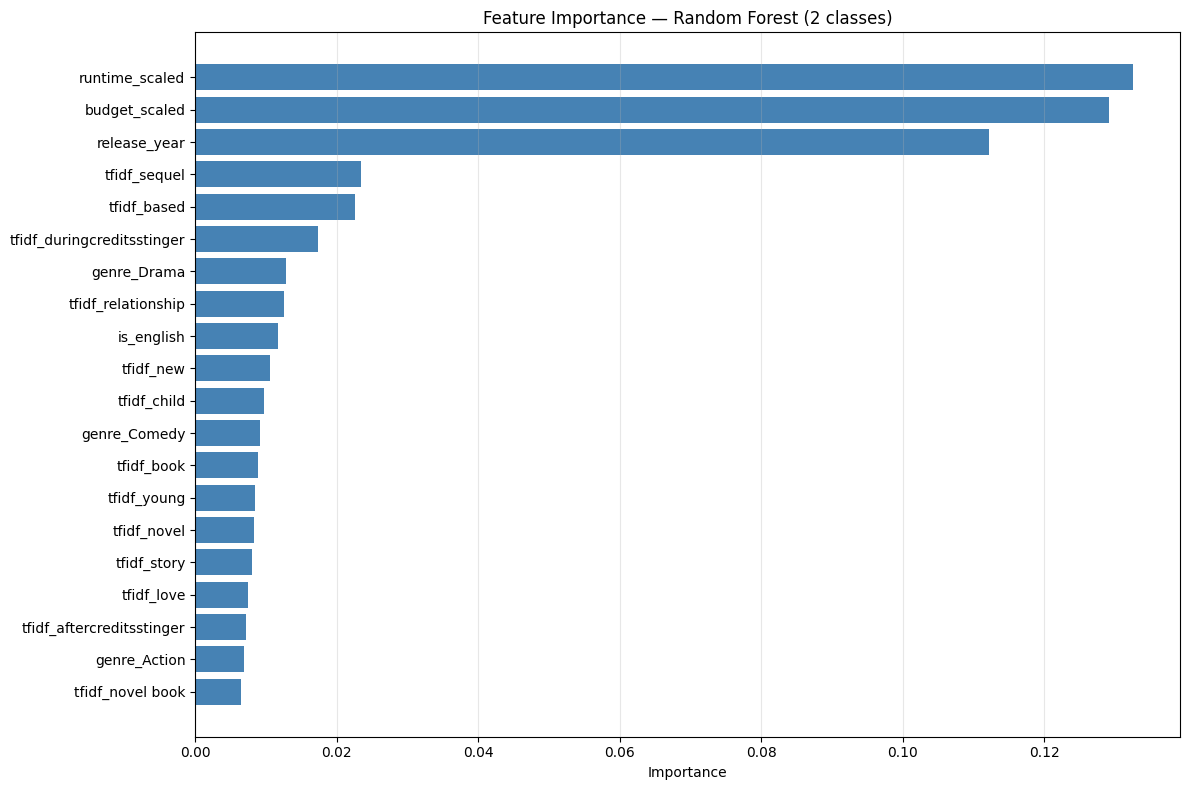


Top 20 variables les plus importantes (2 classes) :
 1. runtime_scaled                 : 0.1326
 2. budget_scaled                  : 0.1292
 3. release_year                   : 0.1121
 4. tfidf_sequel                   : 0.0235
 5. tfidf_based                    : 0.0225
 6. tfidf_duringcreditsstinger     : 0.0174
 7. genre_Drama                    : 0.0128
 8. tfidf_relationship             : 0.0125
 9. is_english                     : 0.0117
10. tfidf_new                      : 0.0106
11. tfidf_child                    : 0.0097
12. genre_Comedy                   : 0.0092
13. tfidf_book                     : 0.0089
14. tfidf_young                    : 0.0085
15. tfidf_novel                    : 0.0083
16. tfidf_story                    : 0.0081
17. tfidf_love                     : 0.0075
18. tfidf_aftercreditsstinger      : 0.0072
19. genre_Action                   : 0.0069
20. tfidf_novel book               : 0.0065


In [148]:
# ==============================
# Feature Importance — modèle final (2 classes)
# ==============================

importances = rf_bin.feature_importances_
indices = np.argsort(importances)[::-1]

n_top = 20

plt.figure(figsize=(12, 8))
plt.barh(
    range(n_top),
    importances[indices[:n_top]][::-1],
    color='steelblue'
)
plt.yticks(
    range(n_top),
    [feature_names[i] for i in indices[:n_top]][::-1]
)
plt.title("Feature Importance — Random Forest (2 classes)")
plt.xlabel("Importance")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\nTop 20 variables les plus importantes (2 classes) :")
for i in range(n_top):
    idx = indices[i]
    print(f"{i+1:2d}. {feature_names[idx]:<30} : {importances[idx]:.4f}")


Interprétation :

Ce graphique présente les 20 variables les plus importantes utilisées par le Random Forest pour distinguer les films Mauvais et Bons.
    Les variables les plus influentes sont :
        runtime_scaled (durée du film),
        budget_scaled,
        release_year.
    Ces variables numériques dominent largement les autres, ce qui montre que des facteurs structurels et économiques jouent un rôle clé dans la rentabilité.
    Les variables textuelles issues du TF-IDF (ex. sequel, based, duringcreditsstinger) apparaissent également, mais avec une importance plus modérée.
    Les genres (Drama, Comedy, Action) ont une influence secondaire mais non négligeable.
Cela confirme que la rentabilité d’un film dépend à la fois :
    de caractéristiques quantitatives fortes (budget, durée, époque),
    et d’indices sémantiques plus fins capturés par le texte.

In [136]:
# ==============================
# Feature Importance par catégorie — RF (2 classes)
# ==============================

# Importance totale des features TF-IDF
tfidf_imp = sum(
    importances[i]
    for i, f in enumerate(feature_names)
    if f.startswith('tfidf_')
)

# Importance totale des genres
genre_imp = sum(
    importances[i]
    for i, f in enumerate(feature_names)
    if f.startswith('genre_')
)

# Autres variables numériques / binaires
other_names = [
    'budget_scaled',
    'runtime_scaled',
    'adult_encoded',
    'is_english',
    'release_year'
]

other_imp = {
    name: importances[feature_names.index(name)]
    for name in other_names
    if name in feature_names
}

# Affichage texte
print("=== IMPORTANCE PAR CATÉGORIE — RF (2 classes) ===")
print(f"  Texte (TF-IDF total)  : {tfidf_imp:.4f} ({tfidf_imp*100:.1f}%)")
print(f"  Genres (total)        : {genre_imp:.4f} ({genre_imp*100:.1f}%)")
for name, imp in other_imp.items():
    print(f"  {name:<22} : {imp:.4f} ({imp*100:.1f}%)")


=== IMPORTANCE PAR CATÉGORIE — RF (2 classes) ===
  Texte (TF-IDF total)  : 0.5437 (54.4%)
  Genres (total)        : 0.0698 (7.0%)
  budget_scaled          : 0.1292 (12.9%)
  runtime_scaled         : 0.1326 (13.3%)
  adult_encoded          : 0.0009 (0.1%)
  is_english             : 0.0117 (1.2%)
  release_year           : 0.1121 (11.2%)


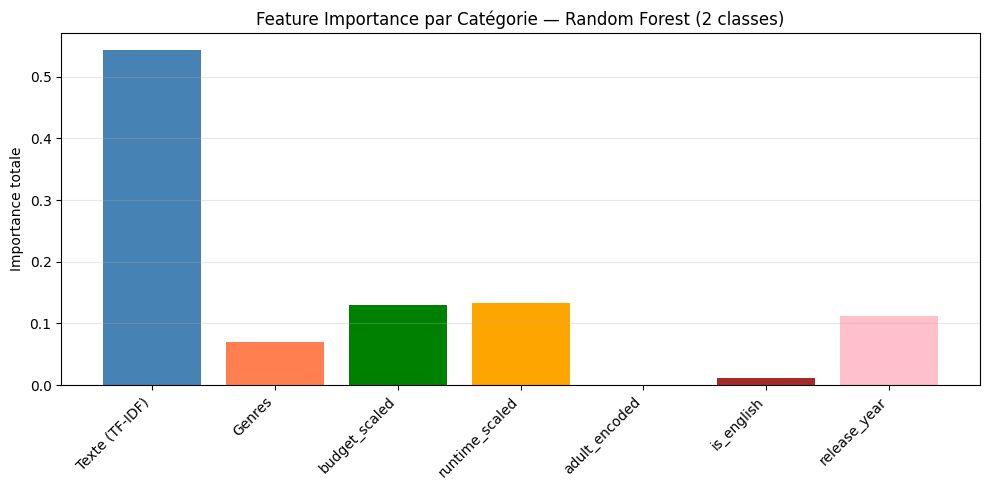

In [137]:
categories = ['Texte (TF-IDF)', 'Genres'] + list(other_imp.keys())
values = [tfidf_imp, genre_imp] + list(other_imp.values())

plt.figure(figsize=(10, 5))
plt.bar(
    categories,
    values,
    color=['steelblue', 'coral', 'green', 'orange', 'purple', 'brown', 'pink']
)
plt.title('Feature Importance par Catégorie — Random Forest (2 classes)')
plt.ylabel('Importance totale')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(
    '../outputs/figures/feature_importance_rf_categories_2classes.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


Interprétation :

Cette figure regroupe les importances par grande catégorie de variables.
Le texte (TF-IDF) représente la part la plus importante de l’information utilisée par le modèle.
Les variables numériques (budget_scaled, runtime_scaled, release_year) ont un poids majeur et complémentaire.
Les genres apportent une information supplémentaire mais restent secondaires.
Les variables binaires (adult_encoded, is_english) ont un impact très faible.
Ce résultat montre que la combinaison :

    
contenu textuel + caractéristiques économiques
est essentielle pour prédire la rentabilité d’un film.



## 7. Analyse des erreurs par classe

In [138]:
# ==============================
# Analyse des erreurs par classe — RF (2 classes)
# ==============================

labels_bin = ["Mauvais", "Bon"]

print("=== ANALYSE DES ERREURS PAR CLASSE (2 classes) ===")
print(f"{'Classe':<10} {'VP':<8} {'FP':<8} {'FN':<8} {'Precision':<12} {'Recall':<12}")
print("-" * 60)

for c in [0, 1]:
    vp = ((y_pred_test_bin == c) & (y_test_bin == c)).sum()
    fp = ((y_pred_test_bin == c) & (y_test_bin != c)).sum()
    fn = ((y_pred_test_bin != c) & (y_test_bin == c)).sum()
    
    prec = vp / (vp + fp) if (vp + fp) > 0 else 0
    rec  = vp / (vp + fn) if (vp + fn) > 0 else 0
    
    print(f"{labels_bin[c]:<10} {vp:<8} {fp:<8} {fn:<8} {prec:<12.4f} {rec:<12.4f}")


=== ANALYSE DES ERREURS PAR CLASSE (2 classes) ===
Classe     VP       FP       FN       Precision    Recall      
------------------------------------------------------------
Mauvais    922      449      435      0.6725       0.6794      
Bon        836      435      449      0.6577       0.6506      


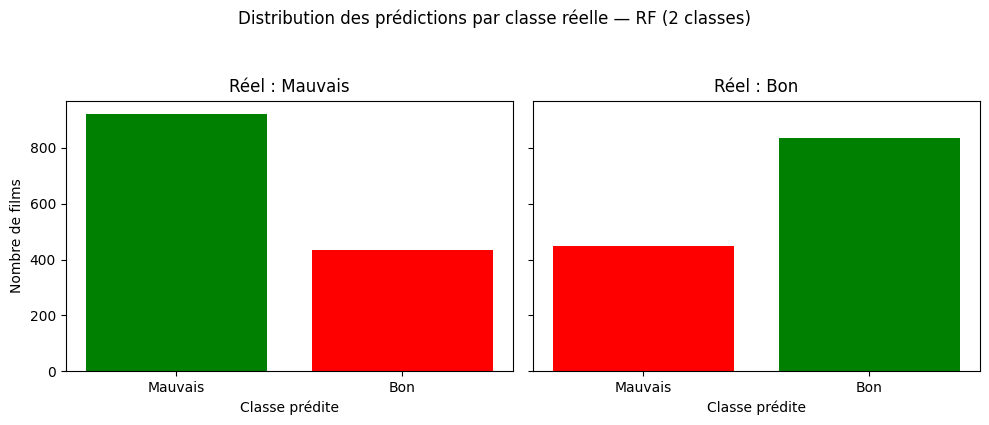

In [139]:
# ==============================
# Distribution des prédictions par classe réelle — RF (2 classes)
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for c in [0, 1]:
    mask = y_test_bin == c
    preds_for_class = y_pred_test_bin[mask]
    unique, counts = np.unique(preds_for_class, return_counts=True)
    
    colors = ['green' if u == c else 'red' for u in unique]
    axes[c].bar(unique, counts, color=colors)
    axes[c].set_title(f"Réel : {labels_bin[c]}")
    axes[c].set_xlabel("Classe prédite")
    axes[c].set_xticks([0, 1])
    axes[c].set_xticklabels(labels_bin)

axes[0].set_ylabel("Nombre de films")
plt.suptitle("Distribution des prédictions par classe réelle — RF (2 classes)", y=1.05)
plt.tight_layout()
plt.savefig(
    "../outputs/figures/analyse_erreurs_rf_2classes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Interprétation :

Ces graphiques analysent les erreurs de prédiction pour chaque classe réelle.
Pour les films réellement Mauvais, la majorité est correctement prédite comme Mauvais, mais une part non négligeable est confondue avec des films Bons.
Pour les films réellement Bons, la majorité est correctement identifiée, avec toutefois des confusions similaires vers la classe Mauvais.
Cette distribution confirme que :
les erreurs se produisent principalement sur des films intermédiaires ou ambigus,
la frontière entre films rentables et non rentables reste floue, ce qui justifie la suppression de la classe Moyen dans cette version binaire.

## 8. Sauvegarde du modèle et des résultats

In [140]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# Sauvegarde modèle + résultats (2 classes)
# ==============================

# Métriques (TEST)
accuracy_bin  = accuracy_score(y_test_bin, y_pred_test_bin)
precision_bin = precision_score(y_test_bin, y_pred_test_bin, zero_division=0)
recall_bin    = recall_score(y_test_bin, y_pred_test_bin, zero_division=0)
f1_bin        = f1_score(y_test_bin, y_pred_test_bin, zero_division=0)

# 1) Sauvegarde du modèle
joblib.dump(rf_bin, '../data/processed/model_random_forest_2classes.joblib')

# 2) Sauvegarde des prédictions
np.save('../data/processed/y_pred_rf_2classes.npy', y_pred_test_bin)

# 3) Sauvegarde des métriques
resultats_rf_bin = {
    'modele': 'Random Forest (2 classes)',
    'n_estimators': rf_bin.n_estimators,
    'max_depth': rf_bin.max_depth,
    'accuracy_test': accuracy_bin,
    'precision_test': precision_bin,
    'recall_test': recall_bin,
    'f1_test': f1_bin,
    'temps_entrainement': training_time_bin,  # ⚠️ doit exister (voir note dessous)
    'n_features': X_train_bin.shape[1],
    'classes': '0=Mauvais (0-1), 1=Bon (3-4), classe 2 retirée',
    'pca': 'Non'
}

pd.DataFrame([resultats_rf_bin]).to_csv('../data/processed/resultats_rf_2classes.csv', index=False)

print("✅ Fichiers sauvegardés (2 classes) :")
print("  → model_random_forest_2classes.joblib")
print("  → resultats_rf_2classes.csv")
print("  → y_pred_rf_2classes.npy")

print("=" * 50)
print("       RÉSUMÉ FINAL — RANDOM FOREST (2 CLASSES)")
print("=" * 50)
print(f"  Accuracy (test) : {accuracy_bin*100:.2f}%")
print(f"  F1-score (test) : {f1_bin:.4f}")
print(f"  Temps entraîn.  : {training_time_bin:.2f}s")
print(f"  Features        : {X_train_bin.shape[1]} (sans PCA)")
print("  Classes         : Mauvais vs Bon (classe Moyenne retirée)")
print("=" * 50)


✅ Fichiers sauvegardés (2 classes) :
  → model_random_forest_2classes.joblib
  → resultats_rf_2classes.csv
  → y_pred_rf_2classes.npy
       RÉSUMÉ FINAL — RANDOM FOREST (2 CLASSES)
  Accuracy (test) : 66.54%
  F1-score (test) : 0.6541
  Temps entraîn.  : 3.08s
  Features        : 325 (sans PCA)
  Classes         : Mauvais vs Bon (classe Moyenne retirée)


Conclusion — Random Forest

Dans ce notebook, nous avons évalué les performances d’un Random Forest Classifier pour prédire la rentabilité des films à partir de variables hétérogènes :

données numériques (budget, durée, année de sortie),

données catégorielles (genres),

données textuelles (résumé via TF-IDF).

Analyse selon le nombre de classes

Nous avons testé le modèle avec plusieurs granularités de classes afin d’évaluer la difficulté du problème :

5 classes (Très mauvais → Très rentable)
Le modèle atteint une accuracy d’environ 37%.
Les résultats montrent une forte confusion entre les classes adjacentes, en particulier la classe Moyen, ce qui indique que la frontière entre les niveaux de rentabilité est floue.

3 classes (Mauvais / Moyen / Bon)
En regroupant les classes extrêmes, l’accuracy augmente à environ 52%.
Cela confirme que réduire le nombre de classes simplifie la tâche, mais la classe Moyen reste difficile à prédire.

2 classes (Mauvais vs Bon)
Après suppression de la classe Moyen, le modèle atteint une accuracy d’environ 66–67% sur le jeu de test, avec un F1-score ≈ 0.65.
Cette configuration fournit un modèle plus robuste et exploitable, notamment pour une utilisation en backend.

Le Random Forest atteint une accuracy de ~67 % et un F1-score de ~0,65 sur le jeu de test, avec des performances équilibrées entre les classes Mauvais et Bon.
L’écart modéré entre les scores d’entraînement et de test indique une bonne généralisation, sans sur-apprentissage.

La reformulation du problème en classification binaire permet de réduire l’ambiguïté inhérente à la classe Moyen et d’améliorer significativement les performances par rapport aux versions à 5 et 3 classes.

Ce modèle constitue une baseline solide pour la prédiction de la rentabilité des films et servira de point de comparaison pertinent avec des modèles plus avancés (ex. XGBoost).